In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from pathlib import Path

for f in Path("../data/processed").glob("*.csv"):
    print(f.name)

01_fund_master_cleaned.csv
02_nav_history_cleaned.csv
03_aum_by_fund_house_cleaned.csv
04_monthly_sip_inflows_cleaned.csv
05_category_inflows_cleaned.csv
06_industry_folio_count_cleaned.csv
07_scheme_performance_cleaned.csv
08_investor_transactions_cleaned.csv
09_portfolio_holdings_cleaned.csv
10_benchmark_indices_cleaned.csv
alpha_beta.csv
fund_scorecard.csv
performance_metrics.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
scheme = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
investor = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

print("NAV:", nav.shape)
print("Scheme:", scheme.shape)
print("Investor:", investor.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Scheme: (40, 19)
Investor: (32778, 13)
Portfolio: (322, 8)


In [4]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nScheme Columns:")
print(scheme.columns.tolist())

print("\nInvestor Columns:")
print(investor.columns.tolist())

print("\nPortfolio Columns:")
print(portfolio.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

Scheme Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Investor Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [5]:
# Merge NAV with Scheme Names

nav_full = nav.merge(
    scheme[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_full.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
var_results = []

for fund in nav_full['scheme_name'].unique():

    temp = nav_full[
        nav_full['scheme_name'] == fund
    ].copy()

    temp = temp.sort_values('date')

    temp['daily_return'] = temp['nav'].pct_change()

    returns = temp['daily_return'].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[
            returns <= var95
        ].mean()

        var_results.append([
            fund,
            var95,
            cvar95
        ])

var_df = pd.DataFrame(
    var_results,
    columns=[
        'scheme_name',
        'VaR95',
        'CVaR95'
    ]
)

var_df.head()

,scheme_name,VaR95,CVaR95
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [7]:
var_df.to_csv(
    "../var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


In [8]:
var_df.sort_values(
    'VaR95'
).head(10)

,scheme_name,VaR95,CVaR95
22,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


Rolling 90-Day Sharpe Ratio

In [9]:
nav_full['date'] = pd.to_datetime(
    nav_full['date']
)

nav_full = nav_full.sort_values(
    ['scheme_name', 'date']
)

Select 5 Funds

In [10]:
top5_funds = [
    'SBI Small Cap Fund - Direct Plan - Growth',
    'Axis Small Cap Fund - Regular - Growth',
    'ABSL Small Cap Fund - Regular - Growth',
    'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
    'ICICI Pru Midcap Fund - Regular - Growth'
]

Create Sharpe Chart

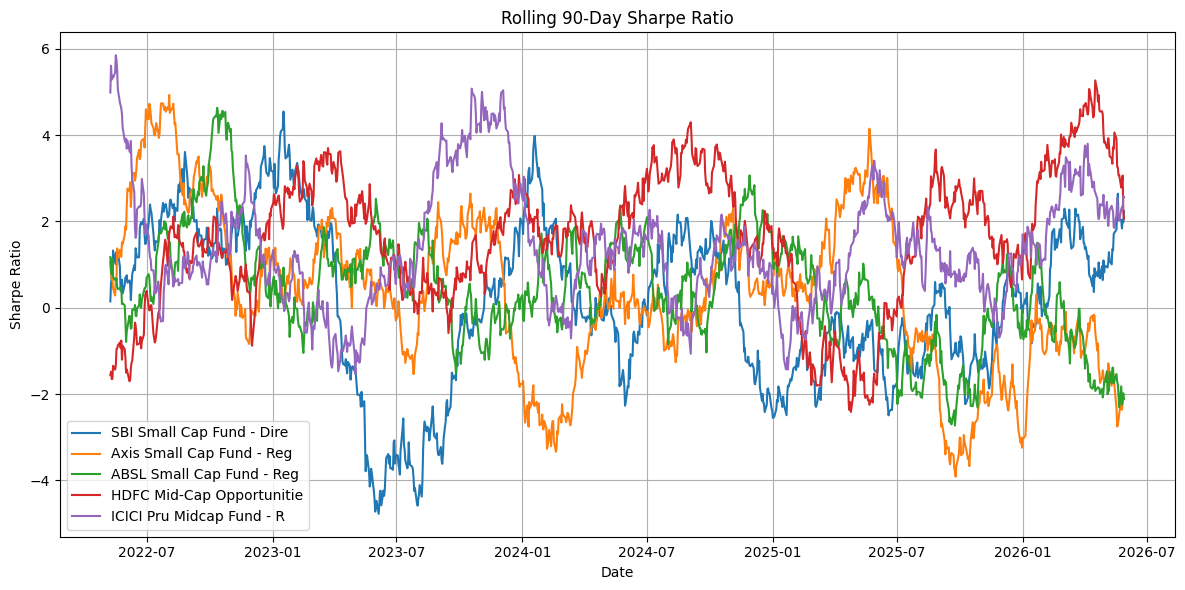

In [11]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = nav_full[
        nav_full['scheme_name'] == fund
    ].copy()

    temp['daily_return'] = (
        temp['nav'].pct_change()
    )

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=fund[:25]
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    '../rolling_sharpe_chart.png'
)

plt.show()

In [12]:
import os

os.path.exists(
    "../rolling_sharpe_chart.png"
)

True

Investor Cohort Analysis

In [13]:
investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

Find First Transaction Year

In [14]:
first_txn = investor.groupby(
    'investor_id'
)['transaction_date'].min()

first_txn.head()

investor_id
INV000001   2024-11-04
INV000002   2024-03-29
INV000003   2024-07-16
INV000004   2024-03-16
INV000005   2024-04-27
Name: transaction_date, dtype: datetime64[us]

Create Cohort Year

In [15]:
cohort_year = first_txn.dt.year

investor['cohort_year'] = investor[
    'investor_id'
].map(cohort_year)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


Average SIP Amount by Cohort

In [16]:
cohort_summary = investor.groupby(
    'cohort_year'
).agg(
    avg_investment=('amount_inr','mean'),
    total_invested=('amount_inr','sum')
).reset_index()

cohort_summary

,cohort_year,avg_investment,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


Top Fund Preference Per Cohort

In [17]:
top_fund = investor.merge(
    scheme[['amfi_code','scheme_name']],
    on='amfi_code'
)

top_fund = (
    top_fund.groupby(
        ['cohort_year','scheme_name']
    )
    .size()
    .reset_index(name='count')
)

top_fund = top_fund.sort_values(
    ['cohort_year','count'],
    ascending=[True,False]
)

top_fund.groupby(
    'cohort_year'
).first()

,scheme_name,count
cohort_year,,
2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
2025,ICICI Pru Liquid Fund - Regular - Growth,12


Identify Highest Investing Cohort

In [18]:
cohort_summary.sort_values(
    'total_invested',
    ascending=False
).head()


,cohort_year,avg_investment,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


SIP Continuity Analysis

In [19]:
sip = investor[
    investor['transaction_type'] == 'SIP'
].copy()

print(sip.shape)

(0, 14)


Sort Data

In [20]:
sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

Calculate Gap Between SIPs

In [21]:
sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days


Investors with 6+ SIP Transactions

In [22]:
sip_counts = sip.groupby(
    'investor_id'
).size()

eligible = sip_counts[
    sip_counts >= 6
].index

sip_eligible = sip[
    sip['investor_id'].isin(eligible)
]

print("Eligible Investors:", len(eligible))

Eligible Investors: 0


Average Gap and Risk Flag

In [23]:
risk_df = sip_eligible.groupby(
    'investor_id'
)['gap_days'].mean().reset_index()

risk_df['status'] = np.where(
    risk_df['gap_days'] > 35,
    'At Risk',
    'Healthy'
)

risk_df.head()

,investor_id,gap_days,status


In [24]:
risk_df['status'].value_counts()

Series([], Name: count, dtype: int64)

In [25]:
investor['transaction_type'].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [5]:
import pandas as pd
import numpy as np

investor = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

print(investor.shape)

(32778, 13)


In [6]:
sip = investor[
    investor['transaction_type'] == 'Sip'
].copy()

print(sip.shape)

(19716, 13)


In [7]:
sip_counts = sip.groupby('investor_id').size()

print("Max SIP transactions per investor:")
print(sip_counts.max())

Max SIP transactions per investor:
12


In [9]:
import pandas as pd

portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv"
)

scheme = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

print(portfolio.shape)
print(scheme.shape)

(322, 8)
(40, 19)


In [10]:
portfolio['weight_sq'] = (
    portfolio['weight_pct'] / 100
) ** 2

hhi = portfolio.groupby(
    'amfi_code'
)['weight_sq'].sum().reset_index()

hhi.columns = ['amfi_code', 'HHI']

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [11]:
hhi = hhi.merge(
    scheme[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Small Cap
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Index


In [12]:
hhi.sort_values(
    'HHI',
    ascending=False
)[['scheme_name', 'category', 'HHI']].head(10)

,scheme_name,category,HHI
11,Axis Bluechip Fund - Regular - Growth,Large Cap,0.206448
3,ABSL Small Cap Fund - Regular - Growth,Small Cap,0.200700
18,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,0.174751
4,UTI Nifty 50 Index Fund - Regular - Growth,Index,0.174709
7,Nippon India Large Cap Fund - Regular - Growth,Large Cap,0.168298
29,Mirae Asset Emerging Bluechip Fund - Regular -...,Large & Mid Cap,0.167930
21,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.157570
22,ICICI Pru Value Discovery Fund - Regular - Growth,Value,0.153794
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,0.152414
23,Kotak Bluechip Fund - Regular - Growth,Large Cap,0.149680


In [13]:
import os

print("VaR Report:",
      os.path.exists("../var_cvar_report.csv"))

print("Sharpe Chart:",
      os.path.exists("../rolling_sharpe_chart.png"))

VaR Report: True
Sharpe Chart: True
